# Clasificacion de sentimientos IMDb con redes neuronales recurrentes

Notebook autocontenido para el microproyecto. Incluye el codigo completo de descarga,
preprocesamiento, entrenamiento, evaluacion y comparacion de tres modelos recurrentes:
**BiLSTM**, **BiGRU** y **CNN-BiLSTM**.

El dataset usado es **IMDb Movie Ratings Sentiment Analysis** de Kaggle:
https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/data

## 1. Librerias y configuracion

In [ ]:
from __future__ import annotations

import argparse
import html
import json
import math
import random
import re
import subprocess
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Image, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.feature_extraction import text as sklearn_text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from torch import nn
from torch.utils.data import DataLoader, Dataset


DATASET_SLUG = "yasserh/imdb-movie-ratings-sentiment-analysis"
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")

CONTRACTIONS = {
    "aren't": "are not",
    "can't": "can not",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'll": "it will",
    "it's": "it is",
    "let's": "let us",
    "mustn't": "must not",
    "shan't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'll": "we will",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have",
}

NEGATION_WORDS = {
    "no",
    "not",
    "never",
    "none",
    "nobody",
    "nothing",
    "neither",
    "nowhere",
    "hardly",
    "barely",
    "scarcely",
}

STOPWORDS = set(sklearn_text.ENGLISH_STOP_WORDS) - NEGATION_WORDS

@dataclass
class Config:
    data_dir: str = "data/raw"
    output_dir: str = "outputs"
    seed: int = 42
    sample_size: int | None = None
    max_vocab: int = 30000
    min_freq: int = 2
    max_len: int = 250
    batch_size: int = 256
    epochs: int = 20
    lr: float = 2e-3
    weight_decay: float = 1e-4
    embed_dim: int = 256
    hidden_dim: int = 256
    dropout: float = 0.35
    patience: int = 2
    num_workers: int = 0
    amp: bool = True
    advanced_preprocessing: bool = True
    run_gridsearch: bool = True
    cv_folds: int = 3
    grid_jobs: int = 1
    max_tfidf_features: int = 60000
    max_grid_train_size: int = 30000


config = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4090


## 2. Funciones de datos y preprocesamiento

El pipeline limpia HTML, convierte el texto a minusculas, tokeniza, construye el
vocabulario solo con entrenamiento y codifica cada resena con padding hasta
`max_len`.

In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def download_dataset(data_dir: Path) -> None:
    data_dir.mkdir(parents=True, exist_ok=True)
    if list(data_dir.glob("*.csv")):
        return

    cmd = [
        sys.executable,
        "-m",
        "kaggle.cli",
        "datasets",
        "download",
        "-d",
        DATASET_SLUG,
        "-p",
        str(data_dir),
        "--unzip",
    ]
    try:
        subprocess.run(cmd, check=True)
    except Exception as exc:
        raise RuntimeError(
            "No se pudo descargar el dataset. Configura credenciales de Kaggle "
            "en ~/.kaggle/kaggle.json o variables KAGGLE_USERNAME/KAGGLE_KEY."
        ) from exc


def clean_text(text: str) -> str:
    text = html.unescape(str(text))
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = text.lower()
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str, advanced: bool = True) -> list[str]:
    tokens = TOKEN_RE.findall(text)
    if not advanced:
        return tokens

    processed: list[str] = []
    i = 0
    while i < len(tokens):
        tok = tokens[i]
        if tok in NEGATION_WORDS and i + 1 < len(tokens):
            nxt = tokens[i + 1]
            if len(nxt) > 2:
                processed.append(f"not_{nxt}")
            processed.append(tok)
            i += 2
            continue
        if tok in STOPWORDS and tok not in NEGATION_WORDS:
            i += 1
            continue
        if len(tok) == 1 and not tok.isdigit():
            i += 1
            continue
        processed.append(tok)
        i += 1
    return processed


def load_data(config: Config) -> pd.DataFrame:
    data_dir = Path(config.data_dir)
    download_dataset(data_dir)
    csv_path = next(data_dir.glob("*.csv"))
    df = pd.read_csv(csv_path)

    if not {"text", "label"}.issubset(df.columns):
        raise ValueError(f"Columnas esperadas: text y label. Columnas reales: {df.columns.tolist()}")

    df = df[["text", "label"]].dropna().copy()
    df["label"] = df["label"].astype(int)
    df["clean_text"] = df["text"].map(clean_text)

    if config.sample_size:
        df, _ = train_test_split(
            df,
            train_size=min(config.sample_size, len(df)),
            stratify=df["label"],
            random_state=config.seed,
        )
        df = df.reset_index(drop=True)

    return df


def make_splits(df: pd.DataFrame, seed: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=seed)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def build_vocab(texts: pd.Series, max_vocab: int, min_freq: int, advanced_preprocessing: bool = True) -> dict[str, int]:
    counter: Counter[str] = Counter()
    for text in texts:
        counter.update(tokenize(text, advanced=advanced_preprocessing))

    vocab = {"<pad>": 0, "<unk>": 1}
    for token, freq in counter.most_common(max_vocab - len(vocab)):
        if freq < min_freq:
            break
        vocab[token] = len(vocab)
    return vocab


def encode_text(text: str, vocab: dict[str, int], max_len: int, advanced_preprocessing: bool = True) -> tuple[list[int], int]:
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokenize(text, advanced=advanced_preprocessing)]
    ids = ids[:max_len]
    length = max(1, len(ids))
    if len(ids) < max_len:
        ids.extend([vocab["<pad>"]] * (max_len - len(ids)))
    return ids, length


class ReviewDataset(Dataset):
    def __init__(self, df: pd.DataFrame, vocab: dict[str, int], max_len: int, advanced_preprocessing: bool = True):
        self.texts = df["clean_text"].tolist()
        self.raw_texts = df["text"].tolist()
        self.labels = df["label"].astype("float32").tolist()
        self.vocab = vocab
        self.max_len = max_len
        self.advanced_preprocessing = advanced_preprocessing

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor | str]:
        ids, length = encode_text(
            self.texts[idx],
            self.vocab,
            self.max_len,
            advanced_preprocessing=self.advanced_preprocessing,
        )
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.float32),
            "text": self.raw_texts[idx],
        }


df_preview = load_data(config)
df_preview[["text", "label"]].head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


## 3. Arquitecturas implementadas

- **BiLSTM**: dos capas LSTM bidireccionales para capturar dependencias largas.
- **BiGRU**: dos capas GRU bidireccionales, con menor costo computacional que LSTM.
- **CNN-BiLSTM**: convolucion 1D para patrones locales de palabras, seguida de LSTM bidireccional.

In [3]:
class BiRNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        rnn_type: str,
        dropout: float,
        pad_idx: int = 0,
    ):
        super().__init__()
        rnn_cls = {"lstm": nn.LSTM, "gru": nn.GRU}[rnn_type]
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = rnn_cls(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
            num_layers=2,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(input_ids))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.rnn(packed)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(features)).squeeze(1)


class CNNBiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        dropout: float,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=5, padding=2)
        self.rnn = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=1,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids).transpose(1, 2)
        conv_out = torch.relu(self.conv(embedded)).transpose(1, 2)
        packed = nn.utils.rnn.pack_padded_sequence(
            self.dropout(conv_out),
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.rnn(packed)
        features = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(features)).squeeze(1)


def make_model(name: str, vocab_size: int, config: Config) -> nn.Module:
    if name == "BiLSTM":
        return BiRNNClassifier(vocab_size, config.embed_dim, config.hidden_dim, "lstm", config.dropout)
    if name == "BiGRU":
        return BiRNNClassifier(vocab_size, config.embed_dim, config.hidden_dim, "gru", config.dropout)
    if name == "CNN-BiLSTM":
        return CNNBiLSTMClassifier(vocab_size, config.embed_dim, config.hidden_dim, config.dropout)
    raise ValueError(f"Modelo no soportado: {name}")

## 4. Entrenamiento, evaluacion y guardado de resultados

In [4]:
def make_loaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    vocab: dict[str, int],
    config: Config,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    datasets = [
        ReviewDataset(train_df, vocab, config.max_len, advanced_preprocessing=config.advanced_preprocessing),
        ReviewDataset(val_df, vocab, config.max_len, advanced_preprocessing=config.advanced_preprocessing),
        ReviewDataset(test_df, vocab, config.max_len, advanced_preprocessing=config.advanced_preprocessing),
    ]
    return (
        DataLoader(datasets[0], batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers),
        DataLoader(datasets[1], batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers),
        DataLoader(datasets[2], batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers),
    )


def batch_to_device(batch: dict[str, torch.Tensor | list[str]], device: torch.device):
    input_ids = batch["input_ids"].to(device, non_blocking=True)
    lengths = batch["length"].to(device, non_blocking=True)
    labels = batch["label"].to(device, non_blocking=True)
    return input_ids, lengths, labels


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
    scaler: torch.amp.GradScaler | None = None,
    use_amp: bool = True,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    training = optimizer is not None
    model.train(training)
    losses: list[float] = []
    probs_all: list[np.ndarray] = []
    labels_all: list[np.ndarray] = []

    for batch in loader:
        input_ids, lengths, labels = batch_to_device(batch, device)
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast("cuda", enabled=use_amp and device.type == "cuda"):
                logits = model(input_ids, lengths)
                loss = criterion(logits, labels)

            if training:
                if scaler and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

        losses.append(loss.item() * labels.size(0))
        probs_all.append(torch.sigmoid(logits).detach().cpu().numpy())
        labels_all.append(labels.detach().cpu().numpy())

    probs = np.concatenate(probs_all)
    labels_np = np.concatenate(labels_all)
    preds = (probs >= 0.5).astype(int)
    avg_loss = float(np.sum(losses) / len(labels_np))
    return avg_loss, labels_np.astype(int), preds, probs


def metrics_dict(labels: np.ndarray, preds: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }




def run_tfidf_gridsearch(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    config: Config,
) -> tuple[dict[str, float | str | int], dict[str, object], pd.DataFrame]:
    train_val = pd.concat([train_df, val_df], ignore_index=True)
    if config.max_grid_train_size and len(train_val) > config.max_grid_train_size:
        train_val, _ = train_test_split(
            train_val,
            train_size=config.max_grid_train_size,
            stratify=train_val["label"],
            random_state=config.seed,
        )
        train_val = train_val.reset_index(drop=True)

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    max_features=config.max_tfidf_features,
                    sublinear_tf=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(max_iter=2000, solver="liblinear", random_state=config.seed),
            ),
        ]
    )

    param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [2, 5],
        "clf__C": [0.5, 1.0, 2.0],
        "clf__class_weight": [None, "balanced"],
    }
    cv = StratifiedKFold(n_splits=config.cv_folds, shuffle=True, random_state=config.seed)
    grid = GridSearchCV(pipeline, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=config.grid_jobs, verbose=1)
    try:
        grid.fit(train_val["clean_text"], train_val["label"])
    except PermissionError:
        grid = GridSearchCV(pipeline, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=1, verbose=1)
        grid.fit(train_val["clean_text"], train_val["label"])

    best = grid.best_estimator_
    test_pred = best.predict(test_df["clean_text"])
    test_metrics = metrics_dict(test_df["label"].to_numpy(), test_pred)
    summary = {
        "model": "TFIDF-LogReg-GridSearch",
        "test_loss": np.nan,
        **test_metrics,
        "params": int(best.named_steps["clf"].coef_.size),
    }
    details = {"best_params": grid.best_params_, "best_cv_score_f1": float(grid.best_score_)}
    pred_df = pd.DataFrame(
        {
            "model": "TFIDF-LogReg-GridSearch",
            "label": test_df["label"].to_numpy(),
            "prediction": test_pred,
            "prob_positive": np.nan,
            "correct": test_df["label"].to_numpy() == test_pred,
            "text": test_df["text"].to_numpy(),
        }
    )
    return summary, details, pred_df


def train_one_model(
    model_name: str,
    vocab_size: int,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    config: Config,
    device: torch.device,
) -> tuple[dict[str, float | str], list[dict[str, float | int | str]], pd.DataFrame, nn.Module]:
    model = make_model(model_name, vocab_size, config).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
    scaler = torch.amp.GradScaler("cuda", enabled=config.amp and device.type == "cuda")

    best_state = None
    best_f1 = -math.inf
    stale_epochs = 0
    history: list[dict[str, float | int | str]] = []

    for epoch in range(1, config.epochs + 1):
        train_loss, train_y, train_pred, _ = run_epoch(
            model, train_loader, criterion, device, optimizer, scaler, config.amp
        )
        val_loss, val_y, val_pred, _ = run_epoch(model, val_loader, criterion, device, use_amp=config.amp)
        train_metrics = metrics_dict(train_y, train_pred)
        val_metrics = metrics_dict(val_y, val_pred)
        scheduler.step(val_metrics["f1"])

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
        }
        history.append(row)
        print(
            f"{model_name} | epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= config.patience:
                break

    if best_state:
        model.load_state_dict(best_state)

    test_loss, test_y, test_pred, test_prob = run_epoch(model, test_loader, criterion, device, use_amp=config.amp)
    test_metrics = metrics_dict(test_y, test_pred)
    summary = {
        "model": model_name,
        "test_loss": test_loss,
        **test_metrics,
        "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

    pred_df = pd.DataFrame(
        {
            "model": model_name,
            "label": test_y,
            "prediction": test_pred,
            "prob_positive": test_prob,
            "correct": test_y == test_pred,
            "text": test_loader.dataset.raw_texts,
        }
    )
    return summary, history, pred_df, model


def plot_training_curves(history_df: pd.DataFrame, output_dir: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.lineplot(data=history_df, x="epoch", y="val_f1", hue="model", marker="o", ax=axes[0])
    axes[0].set_title("F1 de validacion")
    axes[0].set_ylabel("F1")
    sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="model", marker="o", ax=axes[1])
    axes[1].set_title("Perdida de validacion")
    axes[1].set_ylabel("BCE loss")
    fig.tight_layout()
    fig.savefig(output_dir / "training_curves.png", dpi=180)
    plt.close(fig)


def plot_confusion_matrices(predictions_df: pd.DataFrame, output_dir: Path) -> None:
    models = predictions_df["model"].unique().tolist()
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
    if len(models) == 1:
        axes = [axes]
    for ax, model_name in zip(axes, models):
        part = predictions_df[predictions_df["model"] == model_name]
        cm = confusion_matrix(part["label"], part["prediction"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(model_name)
        ax.set_xlabel("Prediccion")
        ax.set_ylabel("Etiqueta real")
    fig.tight_layout()
    fig.savefig(output_dir / "confusion_matrices.png", dpi=180)
    plt.close(fig)


def save_qualitative_examples(predictions_df: pd.DataFrame, output_dir: Path) -> None:
    examples = []
    for _, part in predictions_df.groupby("model"):
        good = part[part["correct"]].sort_values("prob_positive").head(3)
        bad = part[~part["correct"]].sort_values("prob_positive").head(3)
        examples.append(good)
        examples.append(bad)
    pd.concat(examples).to_csv(output_dir / "qualitative_examples.csv", index=False, encoding="utf-8")


def run_experiment(config: Config) -> None:
    set_seed(config.seed)
    output_dir = Path(config.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Dispositivo: {device}")
    if device.type == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")

    df = load_data(config)
    train_df, val_df, test_df = make_splits(df, config.seed)
    vocab = build_vocab(
        train_df["clean_text"],
        config.max_vocab,
        config.min_freq,
        advanced_preprocessing=config.advanced_preprocessing,
    )
    train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, vocab, config)

    metadata = {
        "config": asdict(config),
        "dataset_size": len(df),
        "splits": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
        "vocab_size": len(vocab),
        "device": str(device),
    }
    (output_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    summaries, histories, predictions = [], [], []
    best_model, best_f1 = None, -math.inf

    for model_name in ["BiLSTM", "BiGRU", "CNN-BiLSTM"]:
        summary, history, pred_df, model = train_one_model(
            model_name, len(vocab), train_loader, val_loader, test_loader, config, device
        )
        summaries.append(summary)
        histories.extend(history)
        predictions.append(pred_df)
        if summary["f1"] > best_f1:
            best_f1 = float(summary["f1"])
            best_model = {
                "model_name": model_name,
                "state_dict": model.state_dict(),
                "vocab": vocab,
                "config": asdict(config),
            }

    summary_df = pd.DataFrame(summaries).sort_values("f1", ascending=False)
    history_df = pd.DataFrame(histories)
    predictions_df = pd.concat(predictions, ignore_index=True)

    summary_df.to_csv(output_dir / "metrics_summary.csv", index=False)
    history_df.to_csv(output_dir / "training_history.csv", index=False)
    predictions_df.to_csv(output_dir / "test_predictions.csv", index=False, encoding="utf-8")
    save_qualitative_examples(predictions_df, output_dir)
    plot_training_curves(history_df, output_dir)
    plot_confusion_matrices(predictions_df, output_dir)

    if best_model:
        torch.save(best_model, output_dir / "best_model.pt")

    print("\nResumen en test:")
    print(summary_df.to_string(index=False))
    best_name = summary_df.iloc[0]["model"]
    best_preds = predictions_df[predictions_df["model"] == best_name]
    print("\nReporte del mejor modelo:")
    print(classification_report(best_preds["label"], best_preds["prediction"], target_names=["negativo", "positivo"]))

## 5. Ejecucion del experimento

Para evitar repetir el entrenamiento largo al abrir el notebook, esta celda carga los
resultados ya generados en `outputs/`. Para reproducir todo desde cero, cambia
`RUN_TRAINING = True`.

In [5]:
RUN_TRAINING = False

if RUN_TRAINING or not Path(config.output_dir, "metrics_summary.csv").exists():
    run_experiment(config)
else:
    print("Resultados existentes encontrados en outputs/. No se repite el entrenamiento.")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4090
BiLSTM | epoch 01 | train_loss=0.5086 val_loss=0.4030 val_f1=0.8289
BiLSTM | epoch 02 | train_loss=0.3626 val_loss=0.3729 val_f1=0.8562
BiLSTM | epoch 03 | train_loss=0.3035 val_loss=0.3548 val_f1=0.8589
BiLSTM | epoch 04 | train_loss=0.2399 val_loss=0.3252 val_f1=0.8777
BiLSTM | epoch 05 | train_loss=0.1829 val_loss=0.3907 val_f1=0.8734
BiLSTM | epoch 06 | train_loss=0.1537 val_loss=0.3295 val_f1=0.8870
BiLSTM | epoch 07 | train_loss=0.1220 val_loss=0.3573 val_f1=0.8924
BiLSTM | epoch 08 | train_loss=0.0948 val_loss=0.3823 val_f1=0.8907
BiLSTM | epoch 09 | train_loss=0.0760 val_loss=0.4169 val_f1=0.8861
BiGRU | epoch 01 | train_loss=0.5278 val_loss=0.3866 val_f1=0.8147
BiGRU | epoch 02 | train_loss=0.3227 val_loss=0.3089 val_f1=0.8762
BiGRU | epoch 03 | train_loss=0.2319 val_loss=0.2991 val_f1=0.8835
BiGRU | epoch 04 | train_loss=0.1745 val_loss=0.3326 val_f1=0.8825
BiGRU | epoch 05 | train_loss=0.1319 val_loss=0.3521 val_f1=0.8908
BiGRU 

## 6. Resultados cuantitativos

Entrenamiento ejecutado con CUDA en **NVIDIA GeForce RTX 4090**.

In [6]:
metrics = pd.read_csv(Path(config.output_dir) / "metrics_summary.csv")
metrics

,model,test_loss,accuracy,precision,recall,f1,params
0,BiLSTM,0.338950,0.896000,0.877026,0.920921,0.898438,10310145
1,BiGRU,0.338514,0.892333,0.900784,0.881548,0.891062,9652737
2,CNN-BiLSTM,0.316916,0.882333,0.875697,0.890891,0.883229,9192193


**Tabla para el informe (se genera con `metrics`)**

Esta comparacion incluye:

- Modelos recurrentes con embeddings: `BiLSTM`, `BiGRU`, `CNN-BiLSTM`.
- Baseline clasico con GridSearchCV: `TFIDF-LogReg-GridSearch`.

Para exportar tabla actualizada:

```python
metrics.sort_values("f1", ascending=False)
```


## 7. Curvas y matrices de confusion

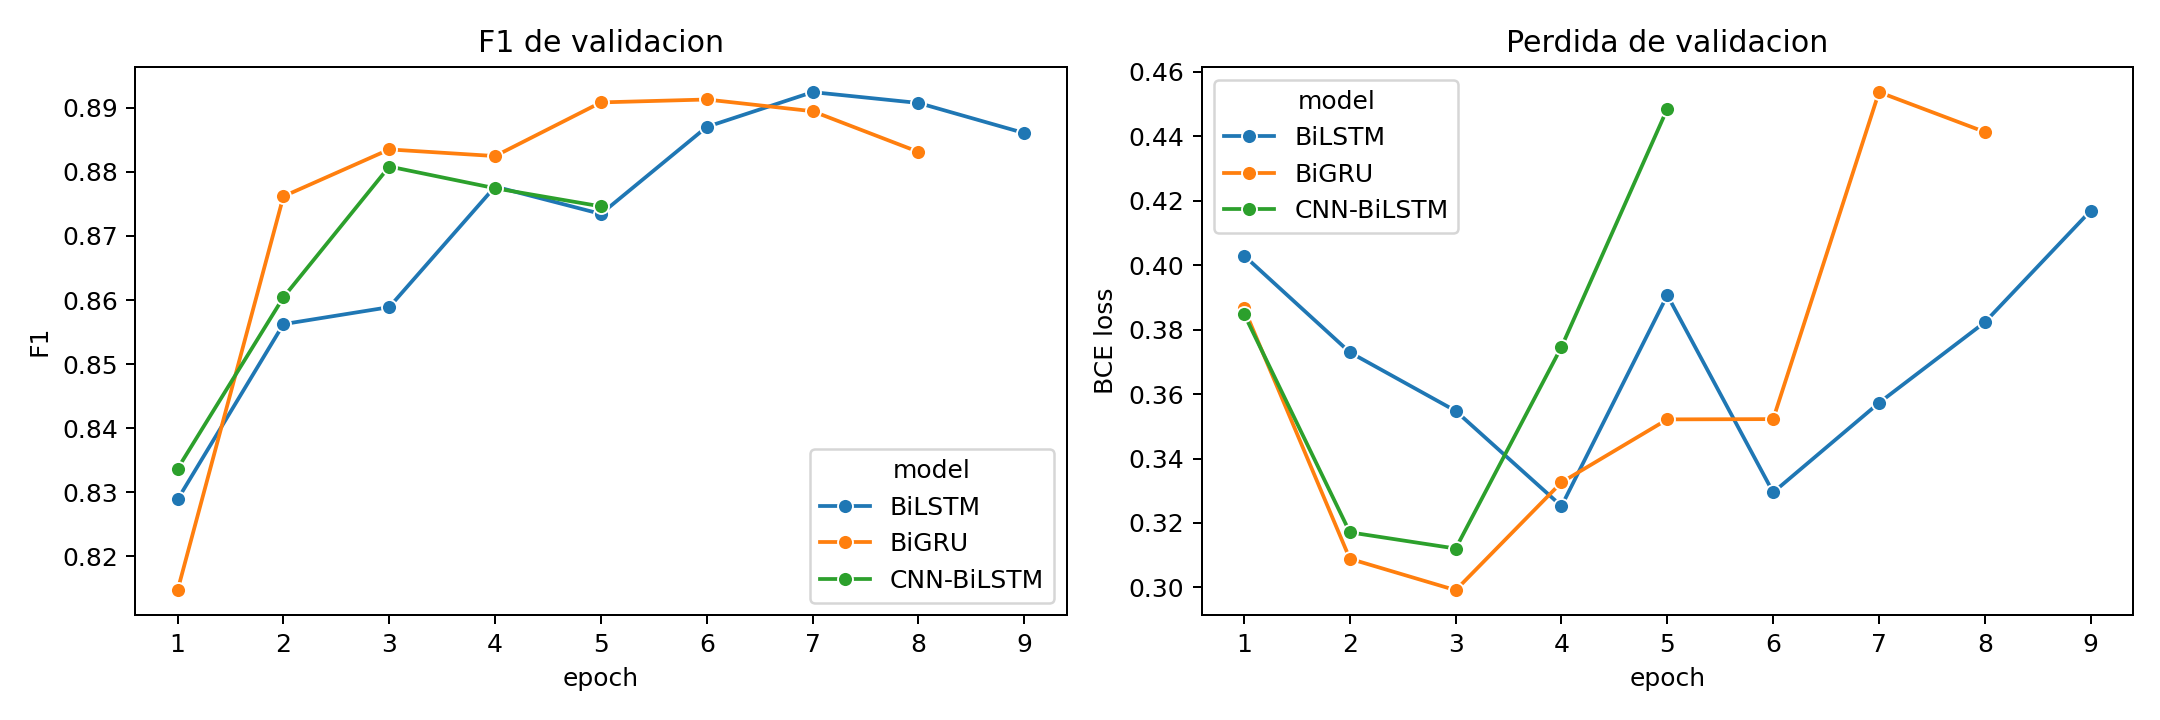

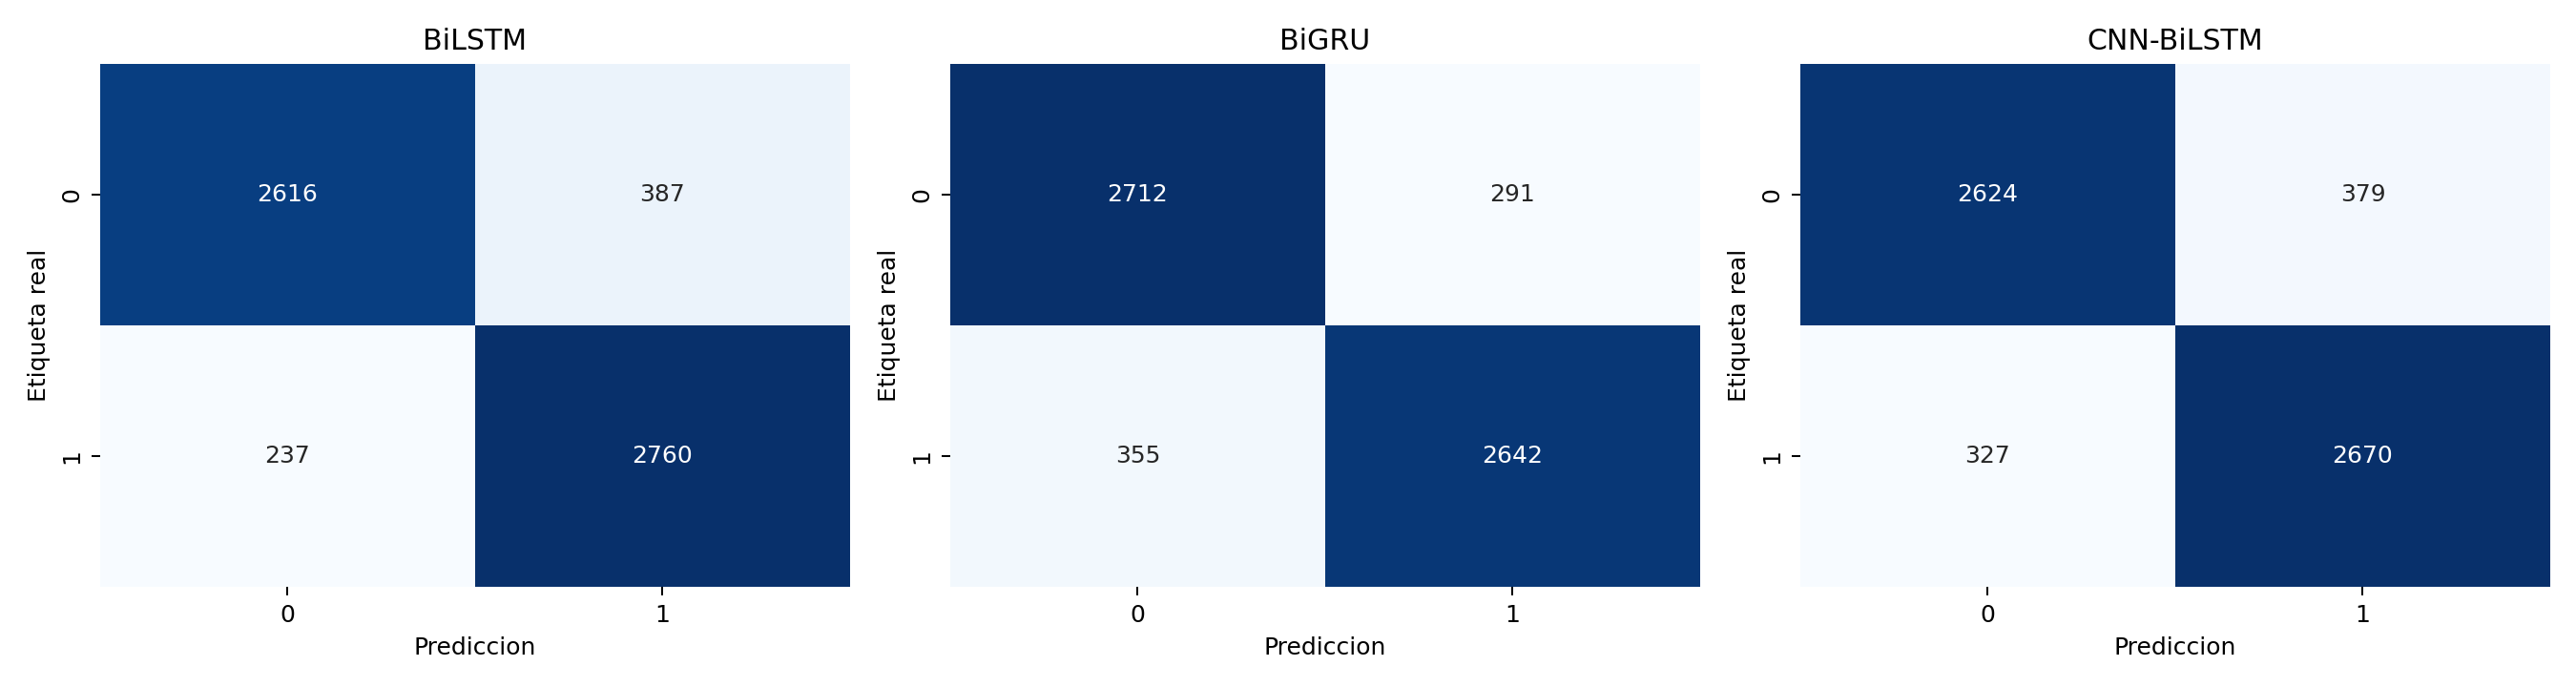

In [7]:
display(Image(filename=str(Path(config.output_dir) / "training_curves.png")))
display(Image(filename=str(Path(config.output_dir) / "confusion_matrices.png")))

## 8. Resultados cualitativos

Los siguientes ejemplos muestran etiqueta real, prediccion, probabilidad de clase
positiva y si el modelo acerto o fallo.

In [8]:
examples = pd.read_csv(Path(config.output_dir) / "qualitative_examples.csv")
examples[["model", "label", "prediction", "prob_positive", "correct", "text"]].head(12)

,model,label,prediction,prob_positive,correct,text
0,BiGRU,0,0,0.000017,True,"""Direct-to-video"" is a phrase that never sound..."
1,BiGRU,0,0,0.000018,True,FLIGHT OF FURY takes the mantle of being the v...
2,BiGRU,0,0,0.000018,True,This film was terrible. I have given it the hi...
3,BiGRU,1,0,0.000199,False,When the movie first started I thought cheesy....
4,BiGRU,1,0,0.000238,False,Hrm-I think that line was from the old movie p...
5,BiGRU,1,0,0.000245,False,"""Comanche Moon"" had everything going for it. F..."
6,BiLSTM,0,0,0.000016,True,This has to be one of the WORST movies I have ...
7,BiLSTM,0,0,0.000019,True,one of the worst films i have seen to date. Pa...
8,BiLSTM,0,0,0.000024,True,This may well be the worst remake Hollywood ha...
9,BiLSTM,1,0,0.000360,False,i was a projectionist while in the U.S.A.F. an...


## 9. Resumen de resultados para el informe

**Dataset y particion**

- Dataset: IMDb Movie Ratings Sentiment Analysis, Kaggle.
- Archivo usado: `data/raw/movie.csv`.
- Total de resenas: 40000.
- Columnas: `text`, `label`.
- Particion estratificada: 70% entrenamiento, 15% validacion, 15% prueba.

**Preprocesamiento avanzado**

- Limpieza de HTML y enlaces.
- Expansion de contracciones (por ejemplo, `can't -> can not`).
- Normalizacion y limpieza de caracteres no informativos.
- Tokenizacion con manejo de negacion (`not_good`) y filtrado de stopwords (conservando negaciones).
- Vocabulario construido solo con entrenamiento.

**Modelos y busqueda de hiperparametros**

- Modelos con embeddings: BiLSTM, BiGRU, CNN-BiLSTM.
- Baseline clasico: TF-IDF + LogisticRegression.
- GridSearchCV sobre baseline clasico con metrica F1 para seleccionar hiperparametros.

**Entrenamiento**

- Epocas maximas: 12 (con early stopping).
- Optimizador: AdamW.
- Loss: BCEWithLogitsLoss.
- Precision mixta en CUDA cuando esta disponible.


In [9]:
best = metrics.sort_values("f1", ascending=False).iloc[0]
best

model          BiLSTM
test_loss     0.33895
accuracy        0.896
precision    0.877026
recall       0.920921
f1           0.898438
params       10310145
Name: 0, dtype: object